In [5]:

# NeuroTwin
# AI-Powered Computational Neuron

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.integrate import solve_ivp

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)


NumPy version: 2.1.3
Pandas version: 2.2.3


In [6]:
import scipy

print("SciPy version:", scipy.__version__)

SciPy version: 1.16.3


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# 1. Hodgkin-Huxley Parameters
C_m = 1.0       # Membrane capacitance (uF/cm^2)

g_Na = 120.0    # Maximum sodium conductance (mS/cm^2)
g_K = 36.0      # Maximum potassium conductance (mS/cm^2)
g_L = 0.3       # Leak conductance (mS/cm^2)

E_Na = 50.0     # Sodium reversal potential (mV)
E_K = -77.0     # Potassium reversal potential (mV)
E_L = -54.4     # Leak reversal potential (mV)


# 2. Alpha and Beta Rate Functions
def alpha_m(V):
    """Sodium activation rate."""
    if abs(V + 40.0) < 1e-7:
        return 1.0
    return 0.1 * (V + 40.0) / (1.0 - np.exp(-(V + 40.0) / 10.0))


def beta_m(V):
    """Sodium activation closing rate."""
    return 4.0 * np.exp(-(V + 65.0) / 18.0)


def alpha_h(V):
    """Sodium inactivation opening rate."""
    return 0.07 * np.exp(-(V + 65.0) / 20.0)


def beta_h(V):
    """Sodium inactivation closing rate."""
    return 1.0 / (1.0 + np.exp(-(V + 35.0) / 10.0))


def alpha_n(V):
    """Potassium activation rate."""
    if abs(V + 55.0) < 1e-7:
        return 0.1
    return 0.01 * (V + 55.0) / (1.0 - np.exp(-(V + 55.0) / 10.0))


def beta_n(V):
    """Potassium activation closing rate."""
    return 0.125 * np.exp(-(V + 65.0) / 80.0)

# 3. External Current

def external_current(t):
    """
    External current injected into the neuron.

    No current before 10 ms.
    Current of 10 uA/cm^2 from 10 to 40 ms.
    """

    if 10.0 <= t <= 40.0:
        return 10.0

    return 0.0


# 4. Hodgkin-Huxley Differential Equations

def hodgkin_huxley(t, y):

    V, m, h, n = y

    # Sodium current
    I_Na = g_Na * (m ** 3) * h * (V - E_Na)

    # Potassium current
    I_K = g_K * (n ** 4) * (V - E_K)

    # Leak current
    I_L = g_L * (V - E_L)

    # External current
    I_ext = external_current(t)

    # Membrane voltage equation
    dVdt = (I_ext - I_Na - I_K - I_L) / C_m

    # Gating equations
    dmdt = alpha_m(V) * (1.0 - m) - beta_m(V) * m

    dhdt = alpha_h(V) * (1.0 - h) - beta_h(V) * h

    dndt = alpha_n(V) * (1.0 - n) - beta_n(V) * n

    return [dVdt, dmdt, dhdt, dndt]



# 5. Initial Conditions

V_initial = -65.0

m_initial = alpha_m(V_initial) / (
    alpha_m(V_initial) + beta_m(V_initial)
)

h_initial = alpha_h(V_initial) / (
    alpha_h(V_initial) + beta_h(V_initial)
)

n_initial = alpha_n(V_initial) / (
    alpha_n(V_initial) + beta_n(V_initial)
)

initial_conditions = [
    V_initial,
    m_initial,
    h_initial,
    n_initial
]

# 6. Simulation Time

t_start = 0.0
t_end = 100.0

t_eval = np.linspace(t_start, t_end, 5000)


# 7. Solve the Differential Equations

solution = solve_ivp(
    hodgkin_huxley,
    (t_start, t_end),
    initial_conditions,
    t_eval=t_eval,
    method="RK45",
    rtol=1e-6,
    atol=1e-8
)


# 8. Extract Results

time = solution.t

voltage = solution.y[0]

m_values = solution.y[1]
h_values = solution.y[2]
n_values = solution.y[3]


# 9. Display Basic Information

print("Simulation completed successfully!")

print("Number of time points:", len(time))

print("Initial membrane voltage:",
      round(voltage[0], 2), "mV")

print("Maximum membrane voltage:",
      round(np.max(voltage), 2), "mV")

print("Minimum membrane voltage:",
      round(np.min(voltage), 2), "mV")

Simulation completed successfully!
Number of time points: 5000
Initial membrane voltage: -65.0 mV
Maximum membrane voltage: 40.26 mV
Minimum membrane voltage: -75.08 mV


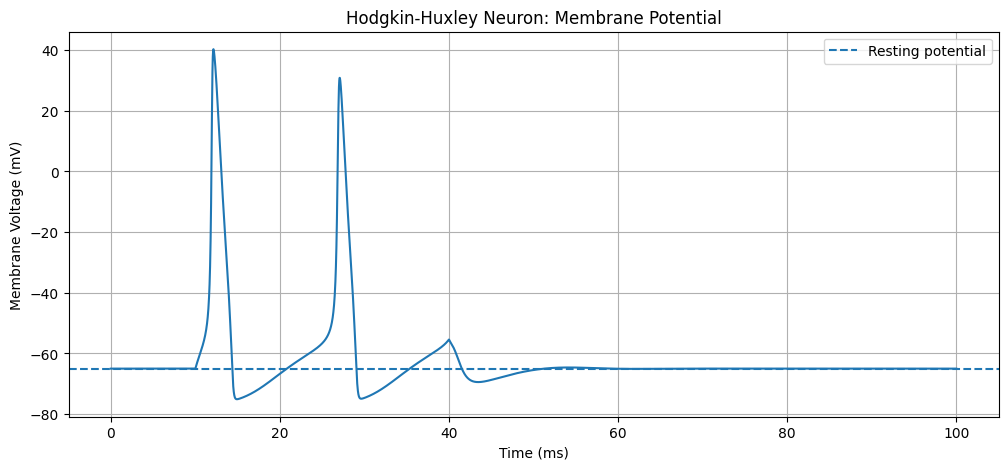

In [8]:
# Step 4: Visualize the Neuron

plt.figure(figsize=(12, 5))

plt.plot(time, voltage)

plt.axhline(
    y=-65,
    linestyle="--",
    label="Resting potential"
)

plt.xlabel("Time (ms)")
plt.ylabel("Membrane Voltage (mV)")
plt.title("Hodgkin-Huxley Neuron: Membrane Potential")

plt.legend()
plt.grid(True)

plt.show()

In [9]:
# Step 5: Validate the Neuron Simulation

# Basic voltage statistics
resting_voltage = voltage[0]
maximum_voltage = np.max(voltage)
minimum_voltage = np.min(voltage)

# Detect spikes using a voltage threshold
spike_threshold = 0.0  # mV

# Find where voltage crosses upward through 0 mV
spike_indices = np.where(
    (voltage[:-1] < spike_threshold) &
    (voltage[1:] >= spike_threshold)
)[0]

spike_times = time[spike_indices]

# Number of detected spikes
spike_count = len(spike_times)

# Simulation duration in seconds
simulation_duration_seconds = (time[-1] - time[0]) / 1000

# Firing rate
firing_rate = spike_count / simulation_duration_seconds

# Display results
print("========== NEURON VALIDATION ==========")

print(f"Initial voltage:     {resting_voltage:.2f} mV")
print(f"Maximum voltage:     {maximum_voltage:.2f} mV")
print(f"Minimum voltage:     {minimum_voltage:.2f} mV")

print(f"\nSpike count:         {spike_count}")
print(f"Spike times:         {spike_times}")

print(f"\nFiring rate:         {firing_rate:.2f} Hz")

print("\n========================================")

========== NEURON VALIDATION ==========
Initial voltage:     -65.00 mV
Maximum voltage:     40.26 mV
Minimum voltage:     -75.08 mV

Spike count:         2
Spike times:         [11.88237648 26.80536107]

Firing rate:         20.00 Hz



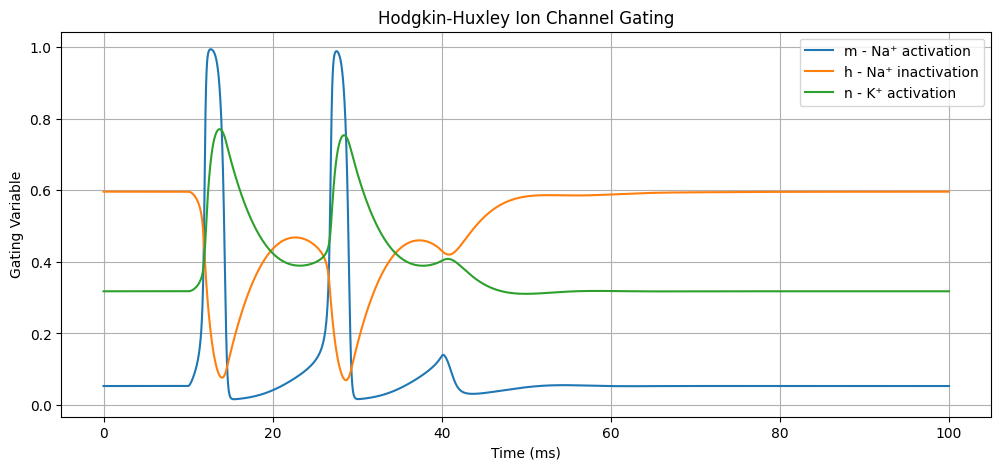

In [10]:
# Step 5B: Ion Channel Gating Variables

plt.figure(figsize=(12, 5))

plt.plot(time, m_values, label="m - Na⁺ activation")
plt.plot(time, h_values, label="h - Na⁺ inactivation")
plt.plot(time, n_values, label="n - K⁺ activation")

plt.xlabel("Time (ms)")
plt.ylabel("Gating Variable")
plt.title("Hodgkin-Huxley Ion Channel Gating")

plt.legend()
plt.grid(True)

plt.show()

In [11]:
# Step 6A: Flexible Neuron Simulator

def simulate_neuron(
    input_current,
    g_Na_value,
    g_K_value,
    g_L_value,
    simulation_time=100.0
):
    # Local neuron parameters

    C_m_value = 1.0

    E_Na_value = 50.0
    E_K_value = -77.0
    E_L_value = -54.4

    # External current

    def current(t):
        if 10.0 <= t <= 40.0:
            return input_current
        return 0.0

    # Hodgkin-Huxley equations

    def equations(t, y):

        V, m, h, n = y

        # Ion currents
        I_Na = (
            g_Na_value *
            (m ** 3) *
            h *
            (V - E_Na_value)
        )

        I_K = (
            g_K_value *
            (n ** 4) *
            (V - E_K_value)
        )

        I_L = (
            g_L_value *
            (V - E_L_value)
        )

        I_ext = current(t)

        # Voltage equation
        dVdt = (
            I_ext -
            I_Na -
            I_K -
            I_L
        ) / C_m_value


        # Gating equations

        # m
        if abs(V + 40.0) < 1e-7:
            a_m = 1.0
        else:
            a_m = (
                0.1 * (V + 40.0) /
                (1.0 - np.exp(-(V + 40.0) / 10.0))
            )

        b_m = 4.0 * np.exp(-(V + 65.0) / 18.0)


        # h
        a_h = 0.07 * np.exp(-(V + 65.0) / 20.0)

        b_h = 1.0 / (
            1.0 +
            np.exp(-(V + 35.0) / 10.0)
        )


        # n
        if abs(V + 55.0) < 1e-7:
            a_n = 0.1
        else:
            a_n = (
                0.01 * (V + 55.0) /
                (1.0 - np.exp(-(V + 55.0) / 10.0))
            )

        b_n = 0.125 * np.exp(-(V + 65.0) / 80.0)


        # Gate derivatives
        dmdt = a_m * (1.0 - m) - b_m * m
        dhdt = a_h * (1.0 - h) - b_h * h
        dndt = a_n * (1.0 - n) - b_n * n

        return [dVdt, dmdt, dhdt, dndt]


    # Initial conditions

    V_initial = -65.0

    # Steady-state gate values
    a_m_initial = alpha_m(V_initial)
    b_m_initial = beta_m(V_initial)

    a_h_initial = alpha_h(V_initial)
    b_h_initial = beta_h(V_initial)

    a_n_initial = alpha_n(V_initial)
    b_n_initial = beta_n(V_initial)

    m_initial = a_m_initial / (a_m_initial + b_m_initial)
    h_initial = a_h_initial / (a_h_initial + b_h_initial)
    n_initial = a_n_initial / (a_n_initial + b_n_initial)


    initial_conditions = [
        V_initial,
        m_initial,
        h_initial,
        n_initial
    ]


    # Numerical simulation

    t_eval = np.linspace(
        0,
        simulation_time,
        2000
    )

    result = solve_ivp(
        equations,
        (0, simulation_time),
        initial_conditions,
        t_eval=t_eval,
        method="RK45",
        rtol=1e-6,
        atol=1e-8
    )


    # Extract voltage

    time_values = result.t
    voltage_values = result.y[0]


    # Detect spikes

    threshold = 0.0

    spike_indices = np.where(
        (voltage_values[:-1] < threshold) &
        (voltage_values[1:] >= threshold)
    )[0]

    spike_times = time_values[spike_indices]

    spike_count = len(spike_times)


    # Calculate firing rate

    duration_seconds = simulation_time / 1000.0

    firing_rate = spike_count / duration_seconds


    # Time to first spike

    if spike_count > 0:
        time_to_first_spike = spike_times[0]
    else:
        time_to_first_spike = np.nan


    # Return results

    return {
        "time": time_values,
        "voltage": voltage_values,
        "spike_count": spike_count,
        "firing_rate": firing_rate,
        "time_to_first_spike": time_to_first_spike,
        "max_voltage": np.max(voltage_values),
        "min_voltage": np.min(voltage_values)
    }


print("Flexible neuron simulator created successfully!")

Flexible neuron simulator created successfully!


In [12]:
# Step 6B: Test Flexible Simulator

test_result = simulate_neuron(
    input_current=10.0,
    g_Na_value=120.0,
    g_K_value=36.0,
    g_L_value=0.3
)

print("========== TEST SIMULATION ==========")

print(
    f"Spike count: {test_result['spike_count']}"
)

print(
    f"Firing rate: {test_result['firing_rate']:.2f} Hz"
)

print(
    f"Maximum voltage: {test_result['max_voltage']:.2f} mV"
)

print(
    f"Minimum voltage: {test_result['min_voltage']:.2f} mV"
)

print(
    f"Time to first spike: "
    f"{test_result['time_to_first_spike']:.2f} ms"
    if not np.isnan(test_result['time_to_first_spike'])
    else "No spike detected"
)

print("\nTest completed successfully!")

========== TEST SIMULATION ==========
Spike count: 2
Firing rate: 20.00 Hz
Maximum voltage: 40.19 mV
Minimum voltage: -75.08 mV
Time to first spike: 11.86 ms

Test completed successfully!


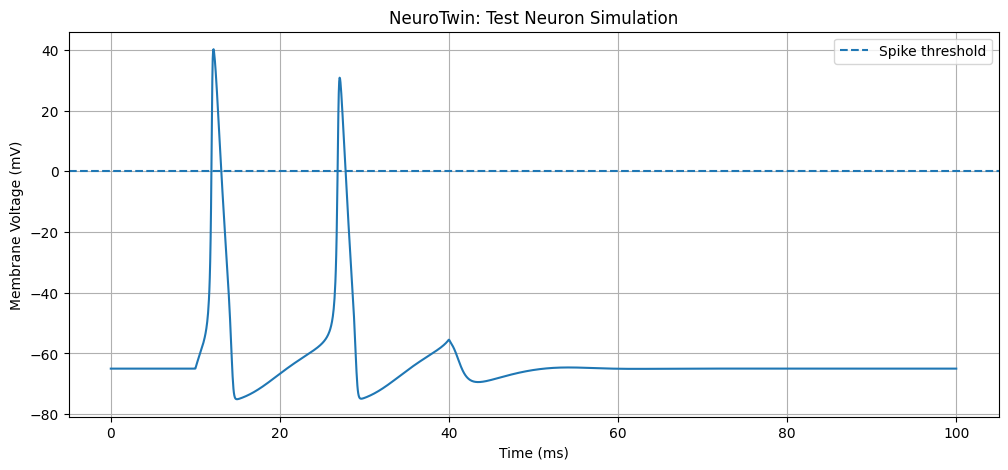

In [13]:
# Step 6C: Plot Test Simulation

plt.figure(figsize=(12, 5))

plt.plot(
    test_result["time"],
    test_result["voltage"]
)

plt.axhline(
    y=0,
    linestyle="--",
    label="Spike threshold"
)

plt.xlabel("Time (ms)")
plt.ylabel("Membrane Voltage (mV)")
plt.title("NeuroTwin: Test Neuron Simulation")

plt.legend()
plt.grid(True)
plt.show()

In [14]:
# STEP 7A — Find Neuron Firing Threshold

test_currents = np.arange(0.0, 16.0, 0.5)

threshold_results = []

for current_value in test_currents:

    result = simulate_neuron(
        input_current=current_value,
        g_Na_value=120.0,
        g_K_value=36.0,
        g_L_value=0.3
    )

    threshold_results.append({
        "input_current": current_value,
        "spike_count": result["spike_count"],
        "firing_rate": result["firing_rate"],
        "fired": int(result["spike_count"] > 0)
    })


threshold_df = pd.DataFrame(threshold_results)

print("Firing-threshold experiment completed!\n")

display(threshold_df)

Firing-threshold experiment completed!



,input_current,spike_count,firing_rate,fired
0,0.0,0,0.0,0
1,0.5,0,0.0,0
2,1.0,0,0.0,0
3,1.5,0,0.0,0
4,2.0,0,0.0,0
5,2.5,1,10.0,1
6,3.0,1,10.0,1
7,3.5,1,10.0,1
8,4.0,1,10.0,1
9,4.5,1,10.0,1


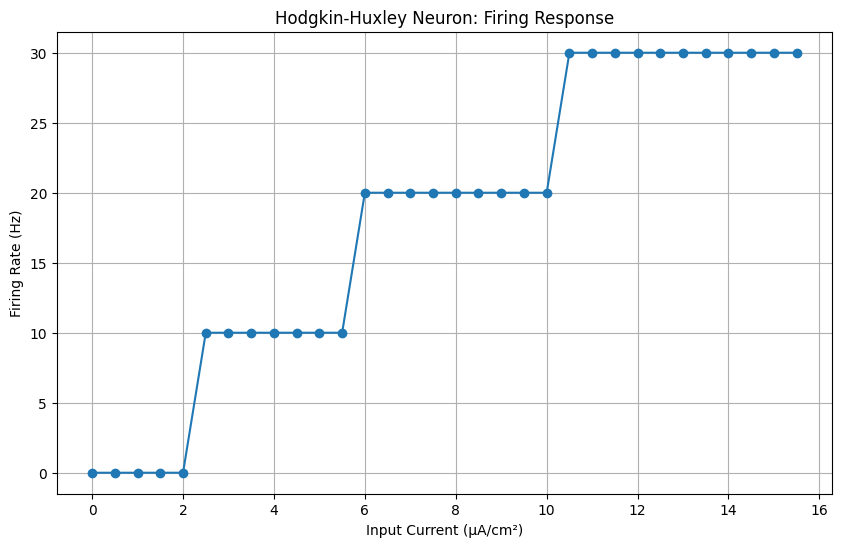

In [15]:
# STEP 7B — Visualize Firing Threshold

plt.figure(figsize=(10, 6))

plt.plot(
    threshold_df["input_current"],
    threshold_df["firing_rate"],
    marker="o"
)

plt.xlabel("Input Current (µA/cm²)")
plt.ylabel("Firing Rate (Hz)")
plt.title("Hodgkin-Huxley Neuron: Firing Response")

plt.grid(True)

plt.show()

In [16]:
# STEP 7C — Identify Firing Transition

firing_rows = threshold_df[
    threshold_df["fired"] == 1
]

non_firing_rows = threshold_df[
    threshold_df["fired"] == 0
]

print("Lowest tested current that produced firing:")

if len(firing_rows) > 0:
    print(
        f"{firing_rows['input_current'].iloc[0]:.2f} µA/cm²"
    )
else:
    print("No firing detected in tested range.")

print("\nHighest tested current that did not produce firing:")

if len(non_firing_rows) > 0:
    print(
        f"{non_firing_rows['input_current'].iloc[-1]:.2f} µA/cm²"
    )
else:
    print("All tested currents produced firing.")

Lowest tested current that produced firing:
2.50 µA/cm²

Highest tested current that did not produce firing:
2.00 µA/cm²


In [17]:
# STEP 7D — Generate Proper Virtual Neuron Dataset

np.random.seed(42)

N_NEURONS = 500

dataset = []

print(f"Generating {N_NEURONS} virtual neurons...")
print("This may take a little while.\n")


for neuron_id in range(1, N_NEURONS + 1):

    # Generate neuron parameters

    # experimentally observed firing threshold.
    input_current = np.random.uniform(0.0, 5.0)

    # Sodium conductance
    g_Na_value = np.random.uniform(100.0, 140.0)

    # Potassium conductance
    g_K_value = np.random.uniform(30.0, 42.0)

    # Leak conductance
    g_L_value = np.random.uniform(0.25, 0.35)

    # Run Hodgkin-Huxley simulation

    result = simulate_neuron(
        input_current=input_current,
        g_Na_value=g_Na_value,
        g_K_value=g_K_value,
        g_L_value=g_L_value
    )

    # Determine whether neuron fired

    fired = int(result["spike_count"] > 0)

    # Store experiment

    dataset.append({
        "neuron_id": neuron_id,
        "input_current": input_current,
        "g_Na": g_Na_value,
        "g_K": g_K_value,
        "g_L": g_L_value,
        "spike_count": result["spike_count"],
        "firing_rate": result["firing_rate"],
        "max_voltage": result["max_voltage"],
        "min_voltage": result["min_voltage"],
        "time_to_first_spike": result["time_to_first_spike"],
        "fired": fired
    })


# Convert to DataFrame

neuron_df = pd.DataFrame(dataset)


print("============================================")
print("Dataset generation completed!")
print("============================================")

print(f"\nDataset shape: {neuron_df.shape}")

Generating 500 virtual neurons...
This may take a little while.

Dataset generation completed!

Dataset shape: (500, 11)


In [19]:
# STEP 7E — Check Dataset

print("========== DATASET CHECK ==========\n")

print("Number of neurons:", len(neuron_df))

print("\nFiring distribution:")

print(
    neuron_df["fired"]
    .value_counts()
    .rename({
        0: "Did Not Fire",
        1: "Fired"
    })
)

print("\nMissing values:")
print(neuron_df.isnull().sum())

print("\nDuplicate rows:")
print(neuron_df.duplicated().sum())

========== DATASET CHECK ==========

Number of neurons: 500

Firing distribution:
fired
Fired           278
Did Not Fire    222
Name: count, dtype: int64

Missing values:
neuron_id                0
input_current            0
g_Na                     0
g_K                      0
g_L                      0
spike_count              0
firing_rate              0
max_voltage              0
min_voltage              0
time_to_first_spike    222
fired                    0
dtype: int64

Duplicate rows:
0


In [20]:
# STEP 7F — Class Distribution

non_firing = (neuron_df["fired"] == 0).sum()
firing = (neuron_df["fired"] == 1).sum()

total = len(neuron_df)

print("Non-firing neurons:", non_firing)
print("Firing neurons:", firing)

print(
    f"\nNon-firing percentage: "
    f"{non_firing / total * 100:.2f}%"
)

print(
    f"Firing percentage: "
    f"{firing / total * 100:.2f}%"
)

Non-firing neurons: 222
Firing neurons: 278

Non-firing percentage: 44.40%
Firing percentage: 55.60%


In [21]:
# STEP 8A — Dataset Overview

print("========== DATASET OVERVIEW ==========\n")

print("Shape:")
print(neuron_df.shape)

print("\nColumns:")
print(list(neuron_df.columns))

print("\nData types:")
print(neuron_df.dtypes)

print("\nMissing values:")
print(neuron_df.isnull().sum())

print("\nDuplicate rows:")
print(neuron_df.duplicated().sum())

========== DATASET OVERVIEW ==========

Shape:
(500, 11)

Columns:
['neuron_id', 'input_current', 'g_Na', 'g_K', 'g_L', 'spike_count', 'firing_rate', 'max_voltage', 'min_voltage', 'time_to_first_spike', 'fired']

Data types:
neuron_id                int64
input_current          float64
g_Na                   float64
g_K                    float64
g_L                    float64
spike_count              int64
firing_rate            float64
max_voltage            float64
min_voltage            float64
time_to_first_spike    float64
fired                    int64
dtype: object

Missing values:
neuron_id                0
input_current            0
g_Na                     0
g_K                      0
g_L                      0
spike_count              0
firing_rate              0
max_voltage              0
min_voltage              0
time_to_first_spike    222
fired                    0
dtype: int64

Duplicate rows:
0


In [22]:
# STEP 8B — Statistical Summary

neuron_df.describe().T

,count,mean,std,min,25%,50%,75%,max
neuron_id,500.0,250.500000,144.481833,1.000000,125.750000,250.500000,375.250000,500.000000
input_current,500.0,2.498031,1.509801,0.025308,1.145690,2.577531,3.878788,4.997069
g_Na,500.0,119.800054,11.443570,100.128731,109.719871,119.806469,129.283829,139.884980
g_K,500.0,35.739220,3.542345,30.059280,32.451817,35.638631,38.670663,41.980170
g_L,500.0,0.302167,0.028449,0.250576,0.277466,0.303822,0.326694,0.349972
spike_count,500.0,0.678000,0.680619,0.000000,0.000000,1.000000,1.000000,2.000000
firing_rate,500.0,6.780000,6.806192,0.000000,0.000000,10.000000,10.000000,20.000000
max_voltage,500.0,-6.857009,49.998405,-65.000000,-62.793179,34.823314,38.310002,41.692115
min_voltage,500.0,-71.309371,4.953631,-76.176010,-75.739673,-75.518393,-65.893988,-65.000000
time_to_first_spike,278.0,14.184790,1.209039,12.606303,13.306653,13.806903,14.807404,19.409705


In [23]:
# STEP 8C — Firing vs Non-Firing Statistics

group_summary = neuron_df.groupby("fired")[
    [
        "input_current",
        "g_Na",
        "g_K",
        "g_L",
        "spike_count",
        "firing_rate",
        "max_voltage",
        "min_voltage"
    ]
].mean()

group_summary

,input_current,g_Na,g_K,g_L,spike_count,firing_rate,max_voltage,min_voltage
fired,,,,,,,,
0,1.063680,119.008712,36.295367,0.304269,0.000000,0.000000,-62.705549,-65.789044
1,3.643449,120.431989,35.295103,0.300489,1.219424,12.194245,37.741466,-75.717690


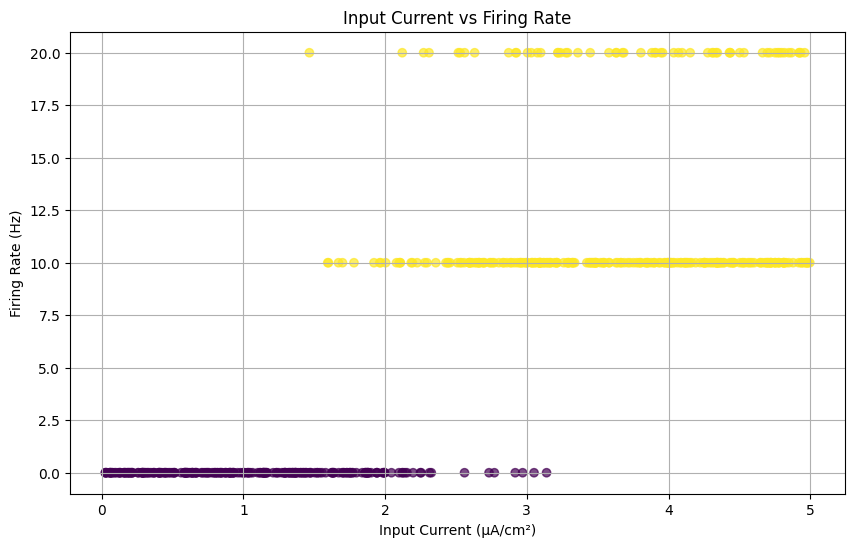

In [24]:
# Input Current vs Firing

plt.figure(figsize=(10, 6))

plt.scatter(
    neuron_df["input_current"],
    neuron_df["firing_rate"],
    c=neuron_df["fired"],
    alpha=0.7
)

plt.xlabel("Input Current (µA/cm²)")
plt.ylabel("Firing Rate (Hz)")
plt.title("Input Current vs Firing Rate")

plt.grid(True)

plt.show()

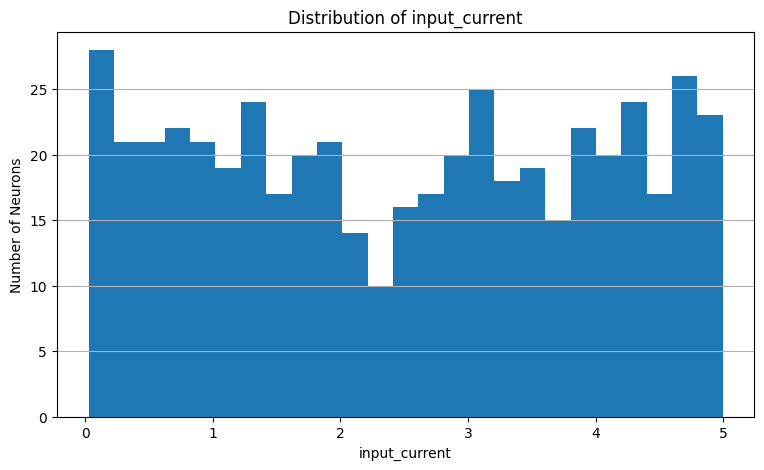

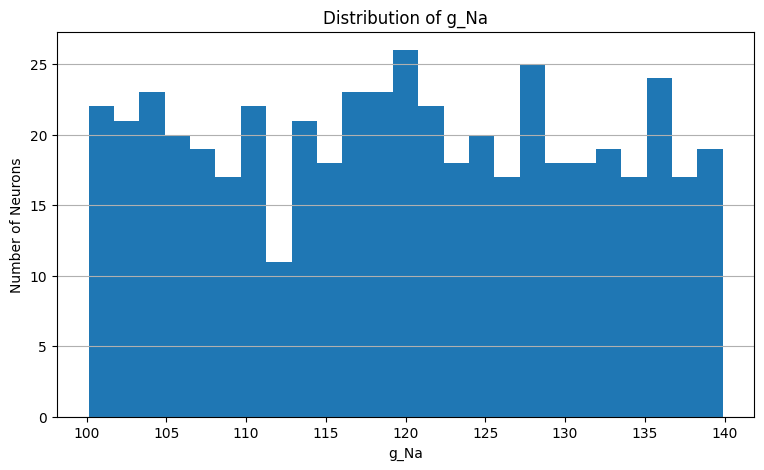

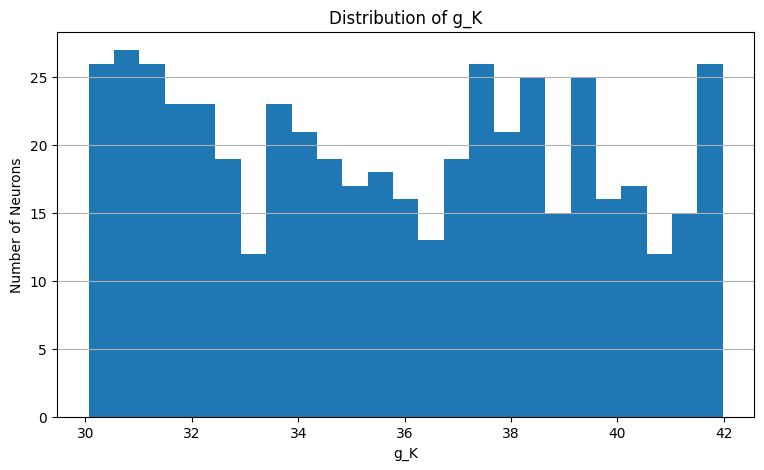

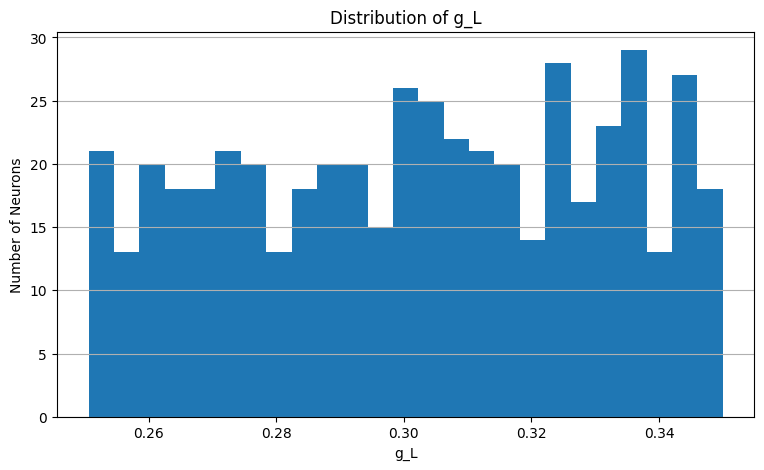

In [25]:
# Feature Distributions

features = [
    "input_current",
    "g_Na",
    "g_K",
    "g_L"
]

for feature in features:

    plt.figure(figsize=(9, 5))

    plt.hist(
        neuron_df[feature],
        bins=25
    )

    plt.xlabel(feature)
    plt.ylabel("Number of Neurons")
    plt.title(f"Distribution of {feature}")

    plt.grid(axis="y")

    plt.show()

/tmp/ipykernel_5300/4205890719.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


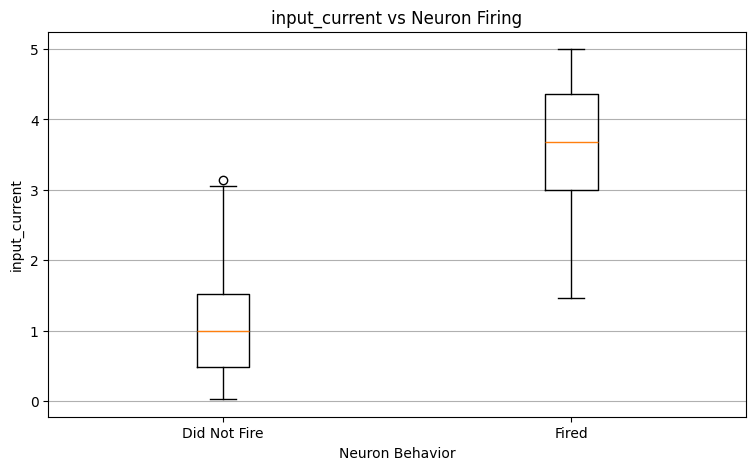

/tmp/ipykernel_5300/4205890719.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


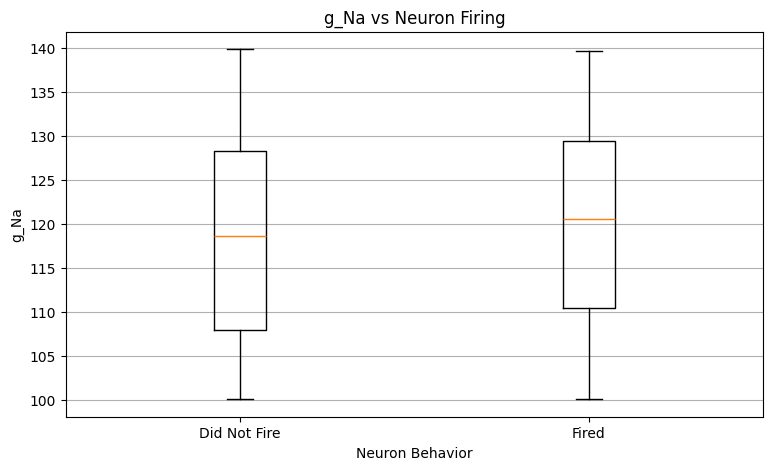

/tmp/ipykernel_5300/4205890719.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


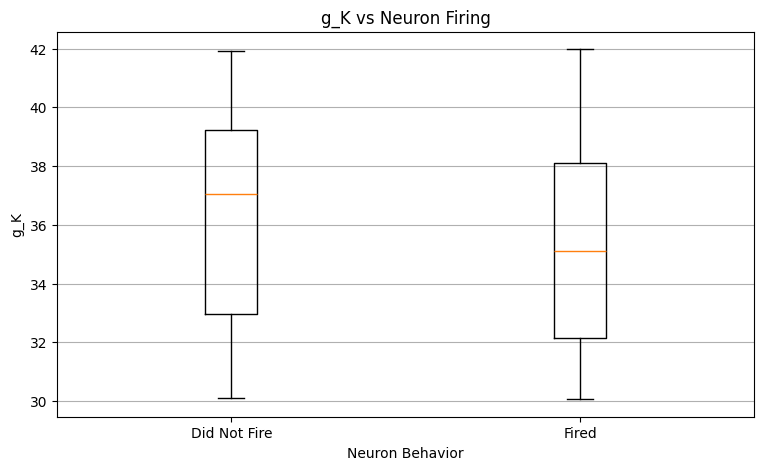

/tmp/ipykernel_5300/4205890719.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


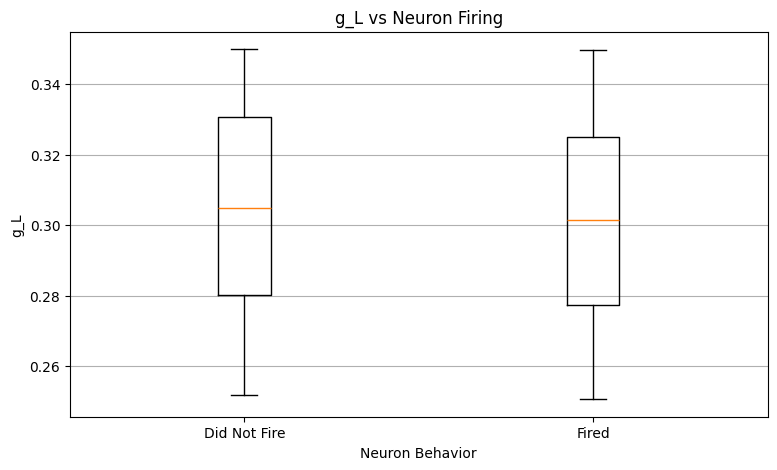

In [26]:
# STEP 8F — Features vs Firing

for feature in features:

    plt.figure(figsize=(9, 5))

    plt.boxplot(
        [
            neuron_df[neuron_df["fired"] == 0][feature],
            neuron_df[neuron_df["fired"] == 1][feature]
        ],
        labels=["Did Not Fire", "Fired"]
    )

    plt.xlabel("Neuron Behavior")
    plt.ylabel(feature)
    plt.title(f"{feature} vs Neuron Firing")

    plt.grid(axis="y")

    plt.show()

In [27]:
# Features
X = neuron_df[
    ["input_current", "g_Na", "g_K", "g_L"]
]

# Target
y = neuron_df["fired"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeatures:")
print(X.head())

print("\nTarget:")
print(y.head())

Feature shape: (500, 4)
Target shape: (500,)

Features:
   input_current        g_Na        g_K       g_L
0       1.872701  138.028572  38.783927  0.309866
1       0.780093  106.239781  30.697003  0.336618
2       3.005575  128.322903  30.247014  0.346991
3       4.162213  108.493564  32.181900  0.268340
4       1.521211  120.990257  35.183340  0.279123

Target:
0    0
1    0
2    1
3    1
4    0
Name: fired, dtype: int64


In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

print("Training targets:", y_train.shape)
print("Testing targets:", y_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Training features: (400, 4)
Testing features: (100, 4)
Training targets: (400,)
Testing targets: (100,)

Training class distribution:
fired
1    222
0    178
Name: count, dtype: int64

Testing class distribution:
fired
1    56
0    44
Name: count, dtype: int64


In [29]:
from sklearn.preprocessing import StandardScaler

# Create the scaler
scaler = StandardScaler()

# Learn scaling parameters from training data only
X_train_scaled = scaler.fit_transform(X_train)

# Apply the same scaling to test data
X_test_scaled = scaler.transform(X_test)

print("Training data shape:", X_train_scaled.shape)
print("Testing data shape:", X_test_scaled.shape)

print("\nFirst 5 scaled training samples:")
print(X_train_scaled[:5])

print("\nMean of scaled training features:")
print(X_train_scaled.mean(axis=0).round(3))

print("\nStandard deviation of scaled training features:")
print(X_train_scaled.std(axis=0).round(3))


Training data shape: (400, 4)
Testing data shape: (100, 4)

First 5 scaled training samples:
[[ 0.16219529  0.99805394 -0.54175296  0.38846146]
 [ 0.42628937  0.68541101  0.2763761  -1.78797223]
 [ 0.19487911  0.7283833   0.61785851 -0.83362655]
 [ 1.54174605  1.35066337 -0.07680019  0.36811869]
 [ 1.65443515 -0.35296651  1.41223343 -1.01017742]]

Mean of scaled training features:
[ 0.  0.  0. -0.]

Standard deviation of scaled training features:
[1. 1. 1. 1.]


In [30]:
from sklearn.linear_model import LogisticRegression

# Create the model
logistic_model = LogisticRegression(random_state=42)

# Train the model
logistic_model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [31]:
# Predict the test neurons
y_pred = logistic_model.predict(X_test_scaled)

print("First 20 actual values:")
print(y_test.values[:20])

print("\nFirst 20 predicted values:")
print(y_pred[:20])

First 20 actual values:
[1 1 1 0 0 1 0 1 1 1 1 0 0 0 1 0 1 0 1 0]

First 20 predicted values:
[0 1 1 0 0 1 0 1 1 1 1 0 0 0 1 0 1 0 1 0]


In [32]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Logistic Regression Results")
print("---------------------------")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Did Not Fire", "Fired"]
))

Logistic Regression Results
---------------------------
Accuracy : 0.9600
Precision: 0.9483
Recall   : 0.9821
F1 Score : 0.9649

Classification Report:
              precision    recall  f1-score   support

Did Not Fire       0.98      0.93      0.95        44
       Fired       0.95      0.98      0.96        56

    accuracy                           0.96       100
   macro avg       0.96      0.96      0.96       100
weighted avg       0.96      0.96      0.96       100



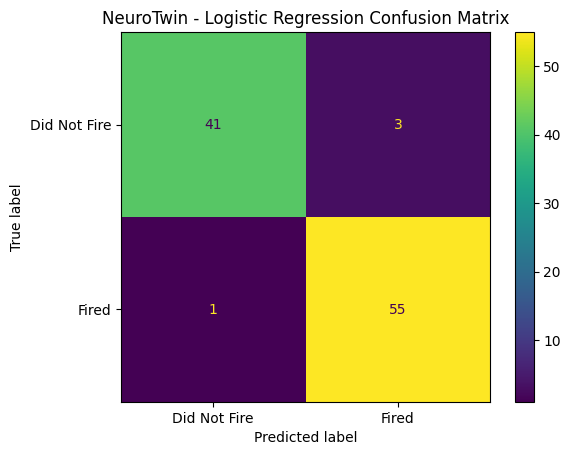

In [33]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Did Not Fire", "Fired"]
)

disp.plot()
plt.title("NeuroTwin - Logistic Regression Confusion Matrix")
plt.show()

In [34]:
from sklearn.ensemble import RandomForestClassifier

# Create the Random Forest model
random_forest_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

# Train the model
random_forest_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [35]:
# Predict the test neurons
rf_pred = random_forest_model.predict(X_test)

print("First 20 Random Forest predictions:")
print(rf_pred[:20])

First 20 Random Forest predictions:
[0 1 1 0 0 1 0 1 1 1 1 0 0 0 1 1 1 0 1 0]


In [36]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Calculate Random Forest metrics
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)

print("Random Forest Results")
print("---------------------")
print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1 Score : {rf_f1:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test,
    rf_pred,
    target_names=["Did Not Fire", "Fired"]
))

Random Forest Results
---------------------
Accuracy : 0.9300
Precision: 0.9298
Recall   : 0.9464
F1 Score : 0.9381

Classification Report:
              precision    recall  f1-score   support

Did Not Fire       0.93      0.91      0.92        44
       Fired       0.93      0.95      0.94        56

    accuracy                           0.93       100
   macro avg       0.93      0.93      0.93       100
weighted avg       0.93      0.93      0.93       100



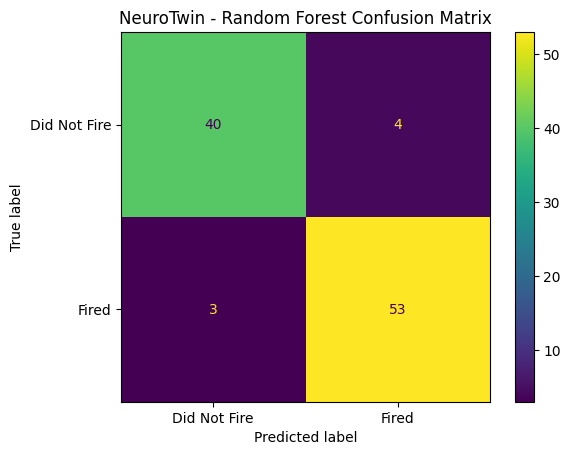

In [37]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

rf_cm = confusion_matrix(y_test, rf_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=rf_cm,
    display_labels=["Did Not Fire", "Fired"]
)

disp.plot()
plt.title("NeuroTwin - Random Forest Confusion Matrix")
plt.show()

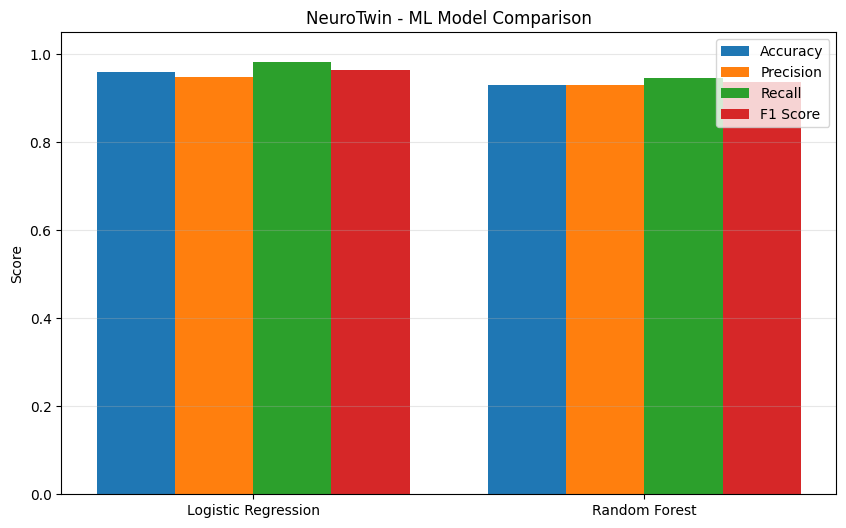

In [38]:
model_names = ["Logistic Regression", "Random Forest"]

accuracy_scores = [
    accuracy,
    rf_accuracy
]

precision_scores = [
    precision,
    rf_precision
]

recall_scores = [
    recall,
    rf_recall
]

f1_scores = [
    f1,
    rf_f1
]

x = np.arange(len(model_names))
width = 0.2

plt.figure(figsize=(10, 6))

plt.bar(x - 1.5 * width, accuracy_scores, width, label="Accuracy")
plt.bar(x - 0.5 * width, precision_scores, width, label="Precision")
plt.bar(x + 0.5 * width, recall_scores, width, label="Recall")
plt.bar(x + 1.5 * width, f1_scores, width, label="F1 Score")

plt.xticks(x, model_names)
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.title("NeuroTwin - ML Model Comparison")
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()

In [39]:
feature_names = [
    "input_current",
    "g_Na",
    "g_K",
    "g_L"
]

coefficients = logistic_model.coef_[0]

coefficient_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

coefficient_df["Absolute_Importance"] = (
    coefficient_df["Coefficient"].abs()
)

coefficient_df = coefficient_df.sort_values(
    "Absolute_Importance",
    ascending=False
)

print(coefficient_df)

         Feature  Coefficient  Absolute_Importance
0  input_current     5.555903             5.555903
2            g_K    -0.996584             0.996584
1           g_Na     0.976354             0.976354
3            g_L    -0.262708             0.262708


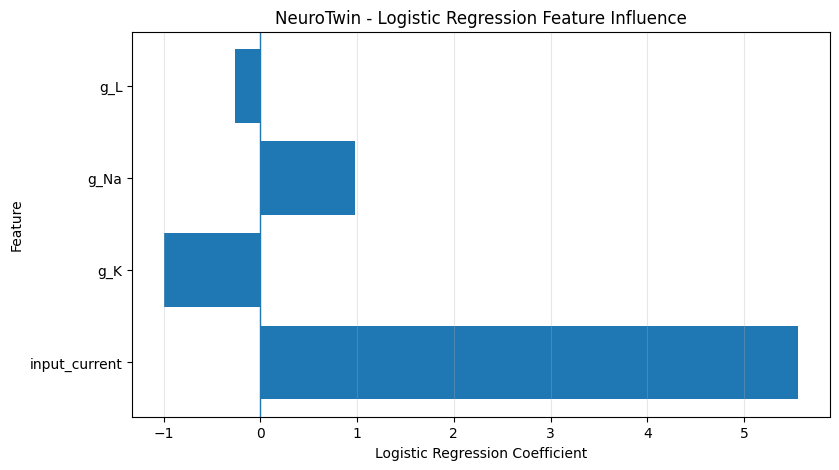

In [40]:
plt.figure(figsize=(9, 5))

plt.barh(
    coefficient_df["Feature"],
    coefficient_df["Coefficient"]
)

plt.axvline(0, linewidth=1)

plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")
plt.title("NeuroTwin - Logistic Regression Feature Influence")
plt.grid(axis="x", alpha=0.3)

plt.show()

Random Forest Feature Importance:


,Feature,Importance
0,input_current,0.853180
2,g_K,0.057207
1,g_Na,0.054543
3,g_L,0.035070


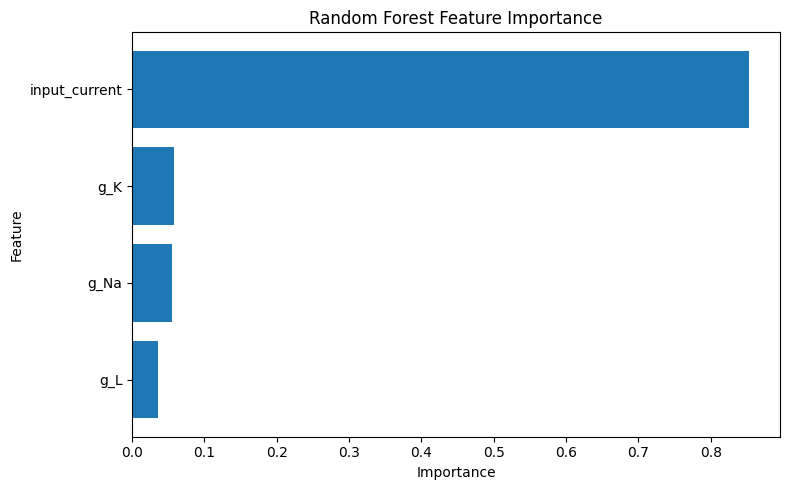

In [43]:
#Random Forest Feature Importance

import pandas as pd
import matplotlib.pyplot as plt

# Get feature importance from the trained Random Forest
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": random_forest_model.feature_importances_
})

# Sort from highest to lowest
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Display the results
print("Random Forest Feature Importance:")
display(feature_importance)

# Create the plot
plt.figure(figsize=(8, 5))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Random Forest Confusion Matrix:
[[40  4]
 [ 3 53]]


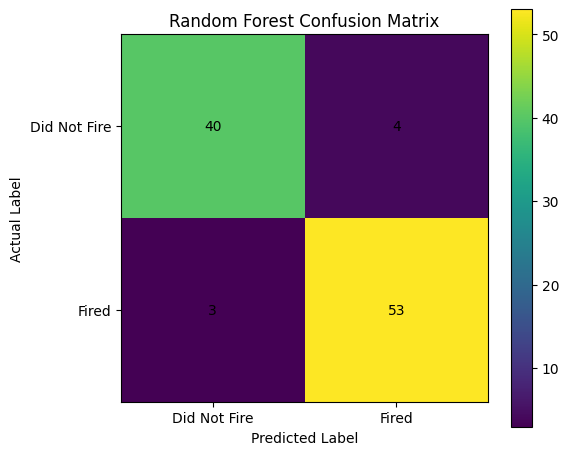

In [44]:

plt.show()# Random Forest Confusion Matrix

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Create confusion matrix
cm = confusion_matrix(y_test, rf_pred)

print("Random Forest Confusion Matrix:")
print(cm)

# Plot confusion matrix
plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.xticks([0, 1], ["Did Not Fire", "Fired"])
plt.yticks([0, 1], ["Did Not Fire", "Fired"])

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Random Forest Confusion Matrix")

# Add numbers inside the matrix
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j],
                 ha="center",
                 va="center")

plt.colorbar()
plt.tight_layout()

Random Forest ROC-AUC: 0.9927


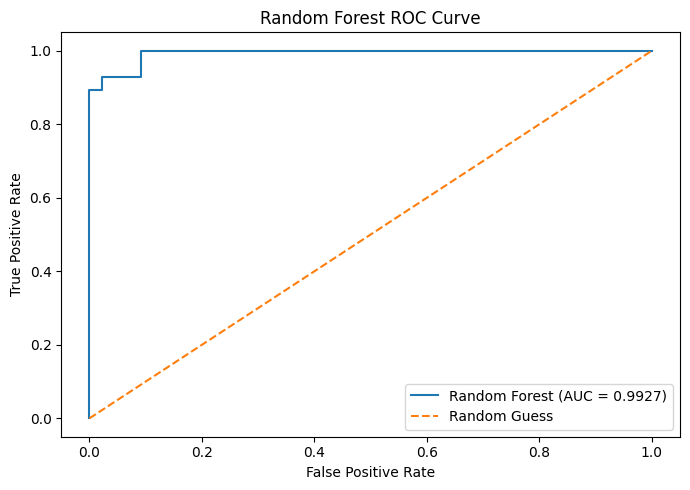

In [45]:
#Random Forest ROC Curve

from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Get probability of the neuron firing
rf_prob = random_forest_model.predict_proba(X_test)[:, 1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, rf_prob)

# Calculate AUC
rf_auc = roc_auc_score(y_test, rf_prob)

print(f"Random Forest ROC-AUC: {rf_auc:.4f}")

# Plot ROC curve
plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Random Forest (AUC = {rf_auc:.4f})"
)

# Random guessing line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Guess"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()

In [46]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Get probability of the neuron firing
logistic_prob = logistic_model.predict_proba(X_test_scaled)[:, 1]

# Calculate ROC curve
logistic_fpr, logistic_tpr, logistic_thresholds = roc_curve(
    y_test,
    logistic_prob
)

# Calculate AUC
logistic_auc = roc_auc_score(
    y_test,
    logistic_prob
)

print(f"Logistic Regression ROC-AUC: {logistic_auc:.4f}")

Logistic Regression ROC-AUC: 0.9968


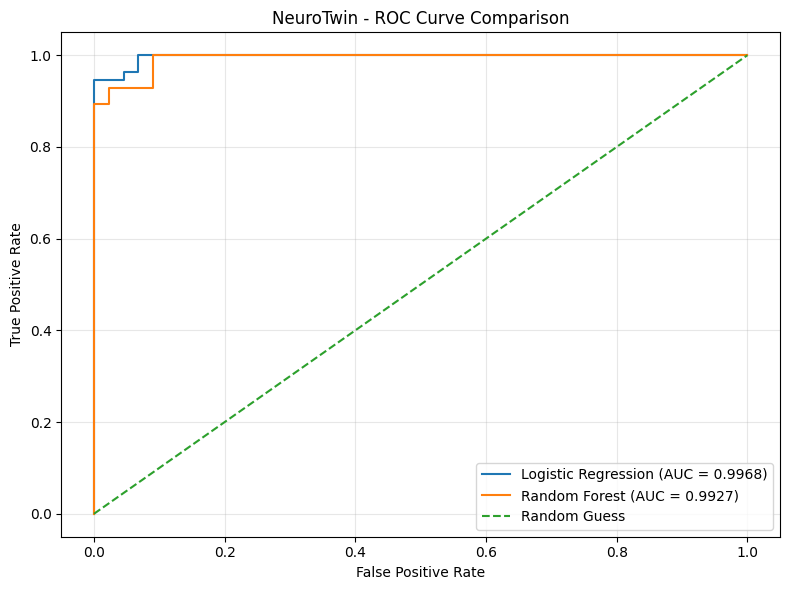

In [47]:
plt.figure(figsize=(8, 6))

# Logistic Regression
plt.plot(
    logistic_fpr,
    logistic_tpr,
    label=f"Logistic Regression (AUC = {logistic_auc:.4f})"
)

# Random Forest
plt.plot(
    fpr,
    tpr,
    label=f"Random Forest (AUC = {rf_auc:.4f})"
)

# Random guessing
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Guess"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("NeuroTwin - ROC Curve Comparison")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [51]:
def predict_neuron(
    input_current,
    g_Na,
    g_K,
    g_L
):
    # Create input data
    new_neuron = pd.DataFrame({
        "input_current": [input_current],
        "g_Na": [g_Na],
        "g_K": [g_K],
        "g_L": [g_L]
    })

    # Scale using the scaler fitted on training data
    new_neuron_scaled = scaler.transform(new_neuron)

    # Make prediction
    prediction = logistic_model.predict(new_neuron_scaled)[0]

    # Get probability of firing
    firing_probability = logistic_model.predict_proba(
        new_neuron_scaled
    )[0, 1]

    # Convert prediction to readable text
    if prediction == 1:
        result = "FIRED"
    else:
        result = "DID NOT FIRE"

    print("NeuroTwin Prediction")
    print("--------------------")
    print(f"Prediction: {result}")
    print(f"Probability of firing: {firing_probability:.2%}")

    return prediction, firing_probability

In [52]:
prediction, probability = predict_neuron(
    input_current=3.5,
    g_Na=120.0,
    g_K=36.0,
    g_L=0.3
)

NeuroTwin Prediction
--------------------
Prediction: FIRED
Probability of firing: 99.12%


In [53]:
# Compare ML prediction with actual HH simulation

input_current = 3.5
g_Na = 120.0
g_K = 36.0
g_L = 0.3

# ML prediction
ml_prediction, ml_probability = predict_neuron(
    input_current=input_current,
    g_Na=g_Na,
    g_K=g_K,
    g_L=g_L
)

# Actual Hodgkin-Huxley simulation
hh_result = simulate_neuron(
    input_current=input_current,
    g_Na_value=g_Na,
    g_K_value=g_K,
    g_L_value=g_L
)

actual_fired = int(hh_result["spike_count"] > 0)

print("\nActual HH Simulation")
print("-------------------")
print(f"Spike count: {hh_result['spike_count']}")
print(f"Firing rate: {hh_result['firing_rate']:.2f} Hz")

print("\nValidation")
print("----------")
print(f"NeuroTwin ML prediction: {'FIRED' if ml_prediction == 1 else 'DID NOT FIRE'}")
print(f"Actual HH result: {'FIRED' if actual_fired == 1 else 'DID NOT FIRE'}")
print(f"Prediction correct: {ml_prediction == actual_fired}")

NeuroTwin Prediction
--------------------
Prediction: FIRED
Probability of firing: 99.12%

Actual HH Simulation
-------------------
Spike count: 1
Firing rate: 10.00 Hz

Validation
----------
NeuroTwin ML prediction: FIRED
Actual HH result: FIRED
Prediction correct: True


In [54]:
#Multiple HH Validation Tests

import pandas as pd

# New neuron parameter combinations for validation
validation_cases = [
    {"input_current": 2.5, "g_Na": 120.0, "g_K": 36.0, "g_L": 0.3},
    {"input_current": 3.0, "g_Na": 120.0, "g_K": 36.0, "g_L": 0.3},
    {"input_current": 3.5, "g_Na": 120.0, "g_K": 36.0, "g_L": 0.3},
    {"input_current": 4.0, "g_Na": 120.0, "g_K": 36.0, "g_L": 0.3},
    {"input_current": 5.0, "g_Na": 110.0, "g_K": 36.0, "g_L": 0.3},
    {"input_current": 3.5, "g_Na": 100.0, "g_K": 36.0, "g_L": 0.3},
    {"input_current": 3.5, "g_Na": 130.0, "g_K": 36.0, "g_L": 0.3},
    {"input_current": 3.5, "g_Na": 120.0, "g_K": 40.0, "g_L": 0.3},
    {"input_current": 3.5, "g_Na": 120.0, "g_K": 30.0, "g_L": 0.3},
    {"input_current": 3.5, "g_Na": 120.0, "g_K": 36.0, "g_L": 0.5}
]

validation_results = []

for case in validation_cases:

    # ML NeuroTwin prediction
    ml_prediction, ml_probability = predict_neuron(
        input_current=case["input_current"],
        g_Na=case["g_Na"],
        g_K=case["g_K"],
        g_L=case["g_L"]
    )

    # Actual Hodgkin-Huxley simulation
    hh_result = simulate_neuron(
        input_current=case["input_current"],
        g_Na_value=case["g_Na"],
        g_K_value=case["g_K"],
        g_L_value=case["g_L"]
    )

    # Actual firing result
    actual_fired = int(hh_result["spike_count"] > 0)

    # Check agreement
    correct = ml_prediction == actual_fired

    validation_results.append({
        "Input Current": case["input_current"],
        "g_Na": case["g_Na"],
        "g_K": case["g_K"],
        "g_L": case["g_L"],
        "ML Prediction": "FIRED" if ml_prediction == 1 else "DID NOT FIRE",
        "ML Probability": ml_probability,
        "HH Result": "FIRED" if actual_fired == 1 else "DID NOT FIRE",
        "Spike Count": hh_result["spike_count"],
        "Firing Rate (Hz)": hh_result["firing_rate"],
        "Correct": correct
    })

# Create results table
validation_df = pd.DataFrame(validation_results)

print("NeuroTwin Multiple HH Validation")
print("--------------------------------")

display(validation_df)

# Calculate validation accuracy
validation_accuracy = validation_df["Correct"].mean() * 100

print(f"\nValidation Agreement: {validation_accuracy:.2f}%")
print(
    f"Correct Predictions: "
    f"{validation_df['Correct'].sum()} / {len(validation_df)}"
)

NeuroTwin Prediction
--------------------
Prediction: FIRED
Probability of firing: 73.09%
NeuroTwin Prediction
--------------------
Prediction: FIRED
Probability of firing: 94.61%
NeuroTwin Prediction
--------------------
Prediction: FIRED
Probability of firing: 99.12%
NeuroTwin Prediction
--------------------
Prediction: FIRED
Probability of firing: 99.86%
NeuroTwin Prediction
--------------------
Prediction: FIRED
Probability of firing: 99.99%
NeuroTwin Prediction
--------------------
Prediction: FIRED
Probability of firing: 95.26%
NeuroTwin Prediction
--------------------
Prediction: FIRED
Probability of firing: 99.63%
NeuroTwin Prediction
--------------------
Prediction: FIRED
Probability of firing: 97.34%
NeuroTwin Prediction
--------------------
Prediction: FIRED
Probability of firing: 99.84%
NeuroTwin Prediction
--------------------
Prediction: FIRED
Probability of firing: 94.65%
NeuroTwin Multiple HH Validation
--------------------------------


,Input Current,g_Na,g_K,g_L,ML Prediction,ML Probability,HH Result,Spike Count,Firing Rate (Hz),Correct
0,2.5,120.0,36.0,0.3,FIRED,0.730865,FIRED,1,10.0,True
1,3.0,120.0,36.0,0.3,FIRED,0.946051,FIRED,1,10.0,True
2,3.5,120.0,36.0,0.3,FIRED,0.991246,FIRED,1,10.0,True
3,4.0,120.0,36.0,0.3,FIRED,0.998634,FIRED,1,10.0,True
4,5.0,110.0,36.0,0.3,FIRED,0.999922,FIRED,1,10.0,True
5,3.5,100.0,36.0,0.3,FIRED,0.952583,FIRED,1,10.0,True
6,3.5,130.0,36.0,0.3,FIRED,0.996294,FIRED,1,10.0,True
7,3.5,120.0,40.0,0.3,FIRED,0.973437,FIRED,1,10.0,True
8,3.5,120.0,30.0,0.3,FIRED,0.998377,FIRED,2,20.0,True
9,3.5,120.0,36.0,0.5,FIRED,0.946519,FIRED,1,10.0,True



Validation Agreement: 100.00%
Correct Predictions: 10 / 10


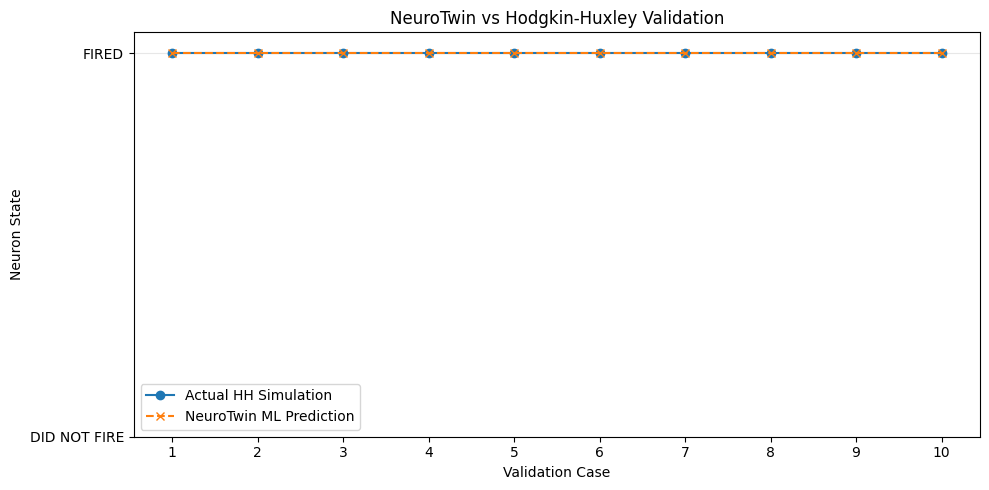

In [55]:
#Visualize NeuroTwin vs HH Validation

import numpy as np
import matplotlib.pyplot as plt

# Convert results to numerical values
actual_values = [
    1 if result == "FIRED" else 0
    for result in validation_df["HH Result"]
]

ml_values = [
    1 if result == "FIRED" else 0
    for result in validation_df["ML Prediction"]
]

# Create case numbers
cases = np.arange(1, len(validation_df) + 1)

# Plot
plt.figure(figsize=(10, 5))

plt.plot(
    cases,
    actual_values,
    marker="o",
    label="Actual HH Simulation"
)

plt.plot(
    cases,
    ml_values,
    marker="x",
    linestyle="--",
    label="NeuroTwin ML Prediction"
)

plt.yticks(
    [0, 1],
    ["DID NOT FIRE", "FIRED"]
)

plt.xlabel("Validation Case")
plt.ylabel("Neuron State")
plt.title("NeuroTwin vs Hodgkin-Huxley Validation")

plt.xticks(cases)
plt.grid(axis="y", alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

In [56]:
#Independent Validation on 50 New Neurons

import random
import pandas as pd

# Number of independent validation cases
n_validation = 50

independent_results = []

for i in range(n_validation):

    # Generate a new random neuron configuration
    input_current = random.uniform(1.0, 5.0)
    g_Na = random.uniform(100.0, 140.0)
    g_K = random.uniform(30.0, 42.0)
    g_L = random.uniform(0.2, 0.5)

    # NeuroTwin ML prediction
    ml_prediction, ml_probability = predict_neuron(
        input_current=input_current,
        g_Na=g_Na,
        g_K=g_K,
        g_L=g_L
    )

    # Actual Hodgkin-Huxley simulation
    hh_result = simulate_neuron(
        input_current=input_current,
        g_Na_value=g_Na,
        g_K_value=g_K,
        g_L_value=g_L
    )

    # Actual HH firing state
    actual_fired = int(hh_result["spike_count"] > 0)

    # Check agreement
    correct = ml_prediction == actual_fired

    independent_results.append({
        "Case": i + 1,
        "Input Current": input_current,
        "g_Na": g_Na,
        "g_K": g_K,
        "g_L": g_L,
        "ML Prediction": "FIRED" if ml_prediction == 1 else "DID NOT FIRE",
        "ML Probability": ml_probability,
        "HH Result": "FIRED" if actual_fired == 1 else "DID NOT FIRE",
        "Spike Count": hh_result["spike_count"],
        "Correct": correct
    })

# Convert results to DataFrame
independent_validation_df = pd.DataFrame(independent_results)

# Calculate statistics
correct_predictions = independent_validation_df["Correct"].sum()
incorrect_predictions = n_validation - correct_predictions
agreement = (correct_predictions / n_validation) * 100

print("Independent NeuroTwin Validation")
print("---------------------------------")
print(f"Total cases       : {n_validation}")
print(f"Correct           : {correct_predictions}")
print(f"Incorrect         : {incorrect_predictions}")
print(f"Agreement         : {agreement:.2f}%")

print("\nValidation Results:")
display(independent_validation_df)

NeuroTwin Prediction
--------------------
Prediction: DID NOT FIRE
Probability of firing: 1.68%
NeuroTwin Prediction
--------------------
Prediction: FIRED
Probability of firing: 92.35%
NeuroTwin Prediction
--------------------
Prediction: FIRED
Probability of firing: 69.37%
NeuroTwin Prediction
--------------------
Prediction: DID NOT FIRE
Probability of firing: 10.50%
NeuroTwin Prediction
--------------------
Prediction: DID NOT FIRE
Probability of firing: 13.84%
NeuroTwin Prediction
--------------------
Prediction: FIRED
Probability of firing: 99.81%
NeuroTwin Prediction
--------------------
Prediction: FIRED
Probability of firing: 88.87%
NeuroTwin Prediction
--------------------
Prediction: DID NOT FIRE
Probability of firing: 45.27%
NeuroTwin Prediction
--------------------
Prediction: DID NOT FIRE
Probability of firing: 3.72%
NeuroTwin Prediction
--------------------
Prediction: FIRED
Probability of firing: 95.25%
NeuroTwin Prediction
--------------------
Prediction: FIRED
Probabi

,Case,Input Current,g_Na,g_K,g_L,ML Prediction,ML Probability,HH Result,Spike Count,Correct
0,1,1.096596,113.414326,33.972506,0.282168,DID NOT FIRE,0.016816,DID NOT FIRE,0,True
1,2,3.183052,133.681676,37.898941,0.483644,FIRED,0.923458,FIRED,1,True
2,3,2.445911,128.687599,38.324533,0.308124,FIRED,0.693680,FIRED,1,True
3,4,1.746905,124.168683,32.427904,0.483192,DID NOT FIRE,0.105036,DID NOT FIRE,0,True
4,5,2.089029,111.912511,33.879936,0.428557,DID NOT FIRE,0.138423,DID NOT FIRE,0,True
5,6,3.879737,112.596247,35.961633,0.221082,FIRED,0.998072,FIRED,1,True
6,7,3.424189,101.408703,37.383025,0.340038,FIRED,0.888702,FIRED,1,True
7,8,2.443444,124.650076,36.694728,0.427587,DID NOT FIRE,0.452676,DID NOT FIRE,0,True
8,9,1.147361,139.656526,33.561370,0.471844,DID NOT FIRE,0.037173,FIRED,1,False
9,10,3.494008,116.734648,36.557295,0.436666,FIRED,0.952544,FIRED,1,True


In [57]:
#Analyze Incorrect NeuroTwin Predictions

# Select cases where ML prediction disagreed with HH
incorrect_cases = independent_validation_df[
    independent_validation_df["Correct"] == False
].copy()

print("Incorrect NeuroTwin Predictions")
print("-------------------------------")

print(f"Number of incorrect cases: {len(incorrect_cases)}")

display(incorrect_cases)

Incorrect NeuroTwin Predictions
-------------------------------
Number of incorrect cases: 4


,Case,Input Current,g_Na,g_K,g_L,ML Prediction,ML Probability,HH Result,Spike Count,Correct
8,9,1.147361,139.656526,33.561370,0.471844,DID NOT FIRE,0.037173,FIRED,1,False
10,11,2.816394,122.579130,38.384212,0.419382,FIRED,0.650667,DID NOT FIRE,0,False
46,47,3.425374,102.207545,38.789328,0.414167,FIRED,0.743925,DID NOT FIRE,0,False
49,50,1.829226,139.375595,38.825044,0.241842,DID NOT FIRE,0.478746,FIRED,1,False


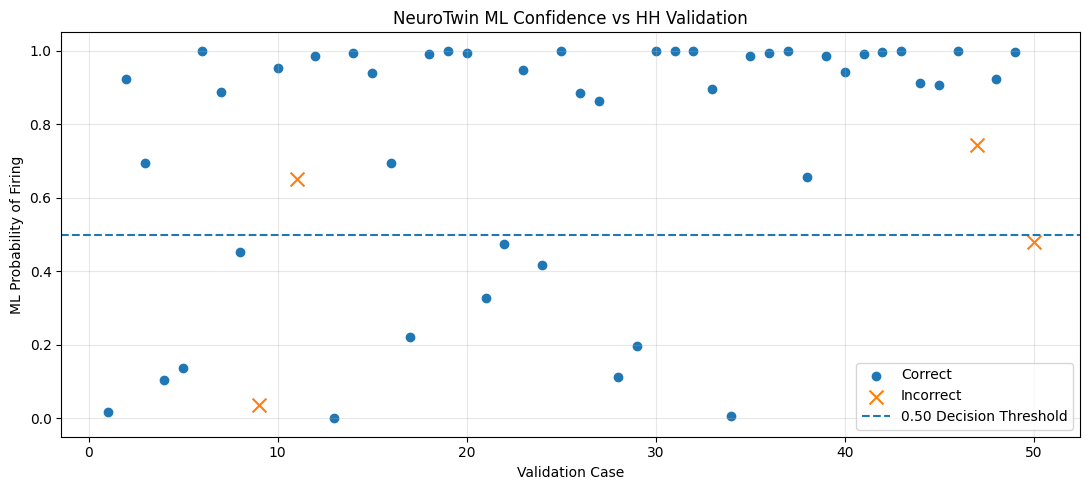

In [58]:
#Visualize ML Probability vs HH Validation

import matplotlib.pyplot as plt

# Create case numbers
cases = independent_validation_df["Case"]

# ML probabilities
probabilities = independent_validation_df["ML Probability"]

# Correct / incorrect cases
correct = independent_validation_df["Correct"]

plt.figure(figsize=(11, 5))

# Plot all ML probabilities
plt.scatter(
    cases[correct],
    probabilities[correct],
    label="Correct"
)

# Plot incorrect predictions
plt.scatter(
    cases[~correct],
    probabilities[~correct],
    marker="x",
    s=100,
    label="Incorrect"
)

# Classification threshold
plt.axhline(
    y=0.5,
    linestyle="--",
    label="0.50 Decision Threshold"
)

plt.xlabel("Validation Case")
plt.ylabel("ML Probability of Firing")
plt.title("NeuroTwin ML Confidence vs HH Validation")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [59]:
#Decision Threshold Analysis

from sklearn.metrics import accuracy_score, precision_score, recall_score

# Get ML probabilities
validation_probabilities = independent_validation_df["ML Probability"].values

# Actual HH results
actual_values = (
    independent_validation_df["HH Result"] == "FIRED"
).astype(int).values

# Thresholds to test
thresholds = [0.30, 0.40, 0.50, 0.60, 0.70, 0.80]

threshold_results = []

for threshold in thresholds:

    # Convert probabilities to predictions
    threshold_predictions = (
        validation_probabilities >= threshold
    ).astype(int)

    # Calculate metrics
    accuracy = accuracy_score(
        actual_values,
        threshold_predictions
    )

    precision = precision_score(
        actual_values,
        threshold_predictions,
        zero_division=0
    )

    recall = recall_score(
        actual_values,
        threshold_predictions,
        zero_division=0
    )

    threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall
    })

# Create results table
threshold_df = pd.DataFrame(threshold_results)

print("Decision Threshold Analysis")
print("---------------------------")

display(threshold_df)

Decision Threshold Analysis
---------------------------


,Threshold,Accuracy,Precision,Recall
0,0.3,0.86,0.853659,0.972222
1,0.4,0.88,0.875000,0.972222
2,0.5,0.92,0.944444,0.944444
3,0.6,0.92,0.944444,0.944444
4,0.7,0.88,0.968750,0.861111
5,0.8,0.90,1.000000,0.861111


Confusion Matrix
----------------
[[12  2]
 [ 2 34]]


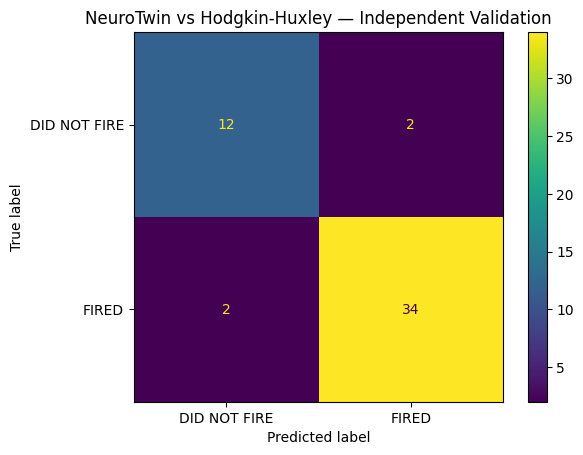

In [60]:
#Confusion Matrix for Independent HH Validation

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Actual HH results
actual_values = (
    independent_validation_df["HH Result"] == "FIRED"
).astype(int)

# ML predictions using the standard 0.50 threshold
ml_predictions = (
    independent_validation_df["ML Probability"] >= 0.50
).astype(int)

# Create confusion matrix
cm = confusion_matrix(actual_values, ml_predictions)

print("Confusion Matrix")
print("----------------")
print(cm)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["DID NOT FIRE", "FIRED"]
)

disp.plot()
plt.title("NeuroTwin vs Hodgkin-Huxley — Independent Validation")
plt.show()

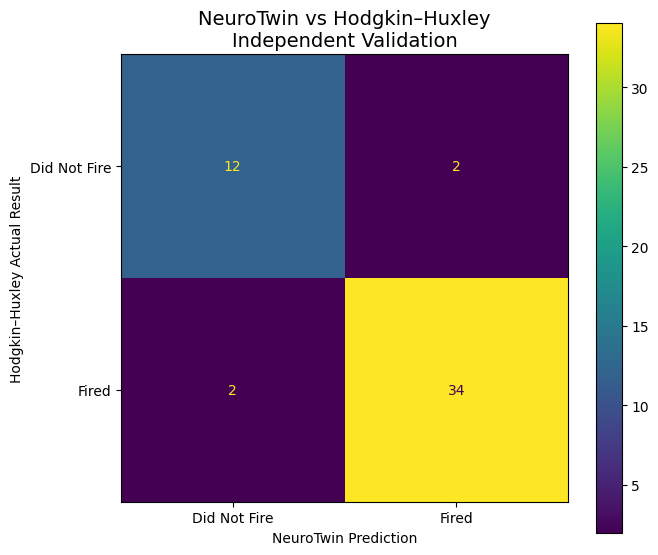

In [61]:
#Publication-Style Confusion Matrix

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Actual HH results
actual_values = (
    independent_validation_df["HH Result"] == "FIRED"
).astype(int)

# NeuroTwin predictions at 0.50 threshold
ml_predictions = (
    independent_validation_df["ML Probability"] >= 0.50
).astype(int)

# Confusion matrix
cm = confusion_matrix(actual_values, ml_predictions)

# Plot
fig, ax = plt.subplots(figsize=(7, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Did Not Fire", "Fired"]
)

disp.plot(
    ax=ax,
    values_format="d"
)

ax.set_title(
    "NeuroTwin vs Hodgkin–Huxley\nIndependent Validation",
    fontsize=14
)

ax.set_xlabel("NeuroTwin Prediction")
ax.set_ylabel("Hodgkin–Huxley Actual Result")

plt.tight_layout()
plt.show()

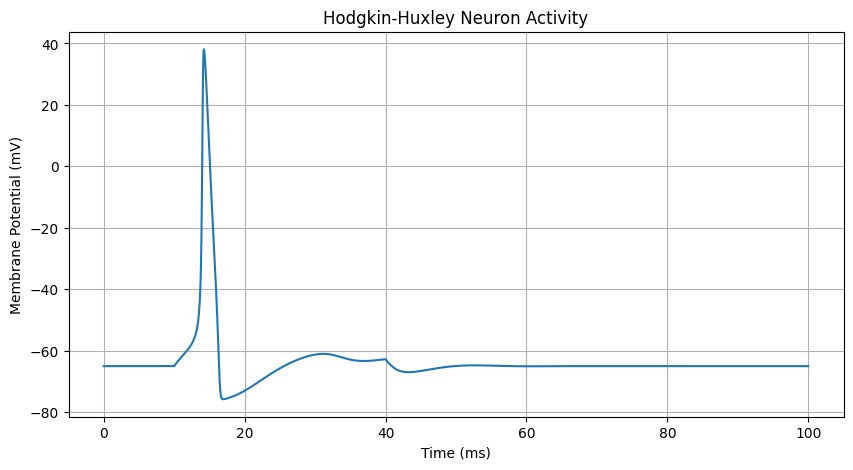

In [62]:
#Visualize Hodgkin-Huxley Neuron Activity

hh_result = simulate_neuron(
    input_current=3.5,
    g_Na_value=120.0,
    g_K_value=36.0,
    g_L_value=0.3
)

plt.figure(figsize=(10, 5))

plt.plot(
    hh_result["time"],
    hh_result["voltage"]
)

plt.xlabel("Time (ms)")
plt.ylabel("Membrane Potential (mV)")
plt.title("Hodgkin-Huxley Neuron Activity")
plt.grid(True)

plt.show()

In [63]:
#  NeuroTwin vs Hodgkin-Huxley

print("NeuroTwin Prediction")
print("--------------------")
print(f"Prediction: {'FIRED' if ml_prediction == 1 else 'DID NOT FIRE'}")
print(f"Probability: {ml_probability:.2%}")

print("\nHodgkin-Huxley")
print("--------------")
print(f"Spike Count: {hh_result['spike_count']}")
print(f"Firing Rate: {hh_result['firing_rate']:.2f} Hz")

print("\nAgreement")
print("---------")
print(f"Match: {'YES' if ml_prediction == actual_fired else 'NO'}")

NeuroTwin Prediction
--------------------
Prediction: DID NOT FIRE
Probability: 47.87%

Hodgkin-Huxley
--------------
Spike Count: 1
Firing Rate: 10.00 Hz

Agreement
---------
Match: NO


In [64]:
# Interactive NeuroTwin

import ipywidgets as widgets
from IPython.display import display

input_current = widgets.FloatSlider(
    value=3.5, min=1.0, max=5.0, step=0.1,
    description="Current:"
)

g_Na = widgets.FloatSlider(
    value=120, min=100, max=140, step=1,
    description="g_Na:"
)

g_K = widgets.FloatSlider(
    value=36, min=30, max=42, step=1,
    description="g_K:"
)

g_L = widgets.FloatSlider(
    value=0.3, min=0.2, max=0.5, step=0.01,
    description="g_L:"
)

def neurotwin_prediction(current, na, k, l):
    prediction, probability = predict_neuron(
        current, na, k, l
    )

    print(
        f"\nPrediction: {'FIRED' if prediction == 1 else 'DID NOT FIRE'}"
    )
    print(f"Probability: {probability:.2%}")

widgets.interact(
    neurotwin_prediction,
    current=input_current,
    na=g_Na,
    k=g_K,
    l=g_L
);

interactive(children=(FloatSlider(value=3.5, description='Current:', max=5.0, min=1.0), FloatSlider(value=120.…

In [65]:
# NeuroTwin + HH Comparison

def compare_neuron(current, na, k, l):

    prediction, probability = predict_neuron(
        current, na, k, l
    )

    hh = simulate_neuron(
        input_current=current,
        g_Na_value=na,
        g_K_value=k,
        g_L_value=l
    )

    actual = int(hh["spike_count"] > 0)

    print(f"NeuroTwin: {'FIRED' if prediction else 'DID NOT FIRE'}")
    print(f"Probability: {probability:.2%}")
    print(f"HH Simulation: {'FIRED' if actual else 'DID NOT FIRE'}")
    print(f"Spike Count: {hh['spike_count']}")
    print(f"Agreement: {'YES' if prediction == actual else 'NO'}")


widgets.interact(
    compare_neuron,
    current=input_current,
    na=g_Na,
    k=g_K,
    l=g_L
);

interactive(children=(FloatSlider(value=3.2, description='Current:', max=5.0, min=1.0), FloatSlider(value=117.…

In [66]:
#Interactive Neuron Waveform

def neuron_waveform(current, na, k, l):

    hh = simulate_neuron(
        input_current=current,
        g_Na_value=na,
        g_K_value=k,
        g_L_value=l
    )

    plt.figure(figsize=(9, 4))
    plt.plot(hh["time"], hh["voltage"])

    plt.xlabel("Time (ms)")
    plt.ylabel("Membrane Potential (mV)")
    plt.title("Hodgkin-Huxley Membrane Potential")
    plt.grid(True)
    plt.show()


widgets.interact(
    neuron_waveform,
    current=input_current,
    na=g_Na,
    k=g_K,
    l=g_L
);

interactive(children=(FloatSlider(value=3.2, description='Current:', max=5.0, min=1.0), FloatSlider(value=117.…

In [67]:
#  NeuroTwin Dashboard

def neurotwin_dashboard(current, na, k, l):

    prediction, probability = predict_neuron(
        current, na, k, l
    )

    hh = simulate_neuron(
        input_current=current,
        g_Na_value=na,
        g_K_value=k,
        g_L_value=l
    )

    actual = int(hh["spike_count"] > 0)

    print("========== NeuroTwin ==========")
    print(f"ML Prediction : {'FIRED' if prediction else 'DID NOT FIRE'}")
    print(f"Probability   : {probability:.2%}")

    print("\n===== Hodgkin-Huxley =====")
    print(f"HH Result     : {'FIRED' if actual else 'DID NOT FIRE'}")
    print(f"Spike Count   : {hh['spike_count']}")
    print(f"Firing Rate   : {hh['firing_rate']:.2f} Hz")

    print("\n========== Validation ==========")
    print(f"Agreement     : {'YES' if prediction == actual else 'NO'}")

    plt.figure(figsize=(9, 4))
    plt.plot(hh["time"], hh["voltage"])
    plt.xlabel("Time (ms)")
    plt.ylabel("Membrane Potential (mV)")
    plt.title("NeuroTwin — Hodgkin-Huxley Activity")
    plt.grid(True)
    plt.show()


widgets.interact(
    neurotwin_dashboard,
    current=input_current,
    na=g_Na,
    k=g_K,
    l=g_L
);

interactive(children=(FloatSlider(value=3.2, description='Current:', max=5.0, min=1.0), FloatSlider(value=117.…

In [68]:
# Save NeuroTwin Model

import joblib

joblib.dump(
    random_forest_model,
    "neurotwin_model.pkl"
)

print("NeuroTwin model saved successfully!")

NeuroTwin model saved successfully!


In [69]:
# Save Feature Information

features = list(X_train.columns)

joblib.dump(
    features,
    "neurotwin_features.pkl"
)

print("Features saved:")
print(features)

Features saved:
['input_current', 'g_Na', 'g_K', 'g_L']


In [70]:
#Create requirements.txt

requirements = """numpy
pandas
matplotlib
scikit-learn
joblib
ipywidgets
"""

with open("requirements.txt", "w") as f:
    f.write(requirements)

print("requirements.txt created successfully!")

requirements.txt created successfully!


In [71]:
import os

print(os.listdir())

['.config', 'neurotwin_model.pkl', 'requirements.txt', 'neurotwin_features.pkl', 'sample_data']


In [72]:
from google.colab import files

files.download("neurotwin_model.pkl")
files.download("neurotwin_features.pkl")
files.download("requirements.txt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>